### General Imports

In [1]:
%load_ext autoreload
%autoreload 2
import sys, os, torch, datetime, time
import numpy as np
sys.path.append("..")
import rfi_ml_S4M
import matplotlib.pyplot as plt

In [2]:
print(f"Is CUDA supported by this system?{torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")

Is CUDA supported by this system?True
CUDA version: 12.1


### Loading Data

In [3]:
# Downloading from main drive (Windows)

data_dir='C:/MLdatasets/raw_LT20'

# Downloading from external drive

# data_dir='D:/MLdatasets/raw_LT20'

### Training Parameters

In [4]:
Np = 2**10 # default is 1024, but it can be changed, keep it to powers of 2, good for power spectra
Nepochs = 10 #default 30
hidden_dim = 2**10 #size of hidden dimension 1
hidden_dim_2 = 2**10 #size of hidden dimension 2 (if different from hidden_dim)
z = 2**4 #minimum dimension

np.random.seed(0) #for debugging
torch.manual_seed(0) #more debugging

In [5]:
s = rfi_ml_S4M.S4Loader(Np=Np) # Calling S4 loader class defined in directory above

all_data = s.slice(data_dir=data_dir) # Loading full dataset

norm_data = s.normalizeData(all_data) # Normalizing full dataset

#norm_shuffle = np.random.shuffle(norm_data) # maybe I should use this

Data dir: C:/MLdatasets/raw_LT20/*.npy
Data Loaded!
Size:  (151246, 1024)
Train data mean:  3.008951126011667e-13
RMS normalization factor:  0.008598209643324178


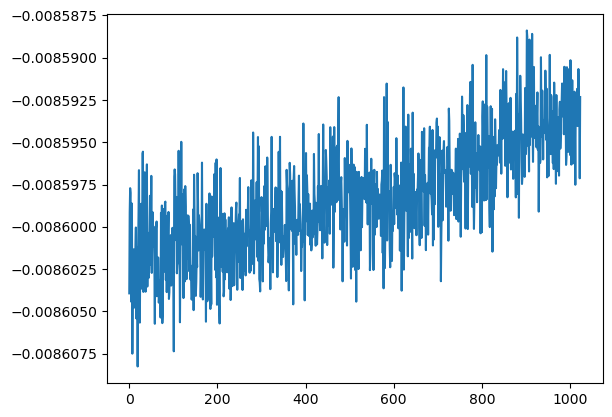

In [11]:
plt.plot(norm_data[1])

In [7]:
np.shape(norm_data)[0]
#b[0]

151246

In [13]:
# Train/Test splitting

trainP = 0.6 # Training data percentage

Ntrain = int(np.shape(norm_data)[0] * trainP)

train_data = norm_data[:Ntrain]
eval_data = norm_data[Ntrain:]

In [16]:
train_data.shape

(90747, 1024)

### Training, Evaluation, and Saving

In [9]:
n = rfi_ml_S4M.RFIDetect(Np = Np, z_dim = z, Nepochs = Nepochs, hidden_dim = hidden_dim, hidden_dim_2 = hidden_dim_2)

In [10]:
n.train(train_data)
del train_data

[  0/30][  0/2835]	Loss: 0.0002397706
[  0/30][100/2835]	Loss: 0.0000002343
[  0/30][200/2835]	Loss: 0.0000001705
[  0/30][300/2835]	Loss: 0.0000003230
[  0/30][400/2835]	Loss: 0.0000001438
[  0/30][500/2835]	Loss: 0.0000000418
[  0/30][600/2835]	Loss: 0.0000000627
[  0/30][700/2835]	Loss: 0.0000000856
[  0/30][800/2835]	Loss: 0.0000000393
[  0/30][900/2835]	Loss: 0.0000000746
[  0/30][1000/2835]	Loss: 0.0000000785
[  0/30][1100/2835]	Loss: 0.0000000270
[  0/30][1200/2835]	Loss: 0.0000004955
[  0/30][1300/2835]	Loss: 0.0000000403
[  0/30][1400/2835]	Loss: 0.0000000198
[  0/30][1500/2835]	Loss: 0.0000002184
[  0/30][1600/2835]	Loss: 0.0000001012
[  0/30][1700/2835]	Loss: 0.0000003083
[  0/30][1800/2835]	Loss: 0.0000000166
[  0/30][1900/2835]	Loss: 0.0000000182
[  0/30][2000/2835]	Loss: 0.0000000372
[  0/30][2100/2835]	Loss: 0.0000007292
[  0/30][2200/2835]	Loss: 0.0000000090
[  0/30][2300/2835]	Loss: 0.0000000675
[  0/30][2400/2835]	Loss: 0.0000000138
[  0/30][2500/2835]	Loss: 0.0000000

In [11]:
rfi_recov = n.evaluate(eval_data)

Epochs:  30
N tests:  60499
Length of timestream:  1024
Input Timestream RMS:  [5.8120863e-06 4.8891898e-06 3.6623335e-06 ... 5.0616077e-06 4.0902801e-06
 8.8115994e-06]
Avg RMS for all tests:  1.9831528e-05 



Saving file...rfi_ml/2024-08-07_11-15-52_overplot_test_0.png
Saving file...rfi_ml/2024-08-07_11-15-52_overplot_test_1.png
Saving file...rfi_ml/2024-08-07_11-15-52_overplot_test_2.png
Saving file...rfi_ml/2024-08-07_11-15-52_overplot_test_3.png
Saving file...rfi_ml/2024-08-07_11-15-52_overplot_test_4.png
Saving file...rfi_ml/2024-08-07_11-15-52_overplot_test_5.png
Saving file...rfi_ml/2024-08-07_11-15-52_overplot_test_6.png
Saving file...rfi_ml/2024-08-07_11-15-52_overplot_test_7.png
Saving file...rfi_ml/2024-08-07_11-15-52_overplot_test_8.png
Saving file...rfi_ml/2024-08-07_11-15-52_overplot_test_9.png
Saving file...rfi_ml/2024-08-07_11-15-52_overplot_test_10.png
Saving file...rfi_ml/2024-08-07_11-15-52_overplot_test_11.png


KeyboardInterrupt: 

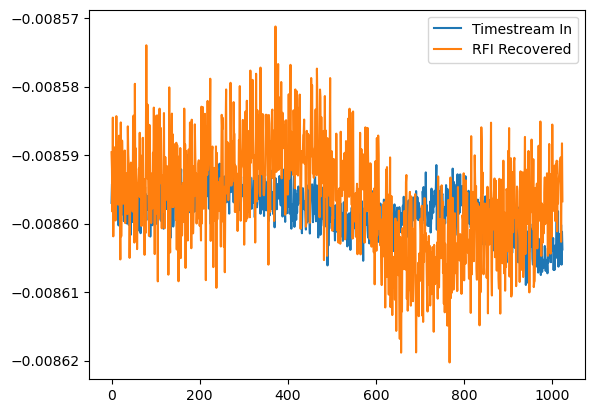

In [12]:
n.plot_eval(rfi_recov, eval_data) # Plotting the results